<h1 style="color:#56B4E9;">Week 7 — Day 4</h1>

<h2 style="color:#0072B2;">Attention & Transformers for Text Classification</h2>

### IMDb Movie Review Sentiment Classification

During Day 3, sequential ECG measurements were processed using RNN and LSTM models. Those models read a sequence one step at a time and carry information through recurrent memory.

Today, the task changes to text classification. We study how attention allows every token to examine the relevance of other tokens directly, then use a pre-trained DistilBERT Transformer to classify IMDb movie reviews as negative or positive.

<h2 style="color:#0072B2;">Learning Objectives</h2>

By the end of this notebook, we will be able to:

- Explain the sequential limitation of RNN and LSTM models.
- Explain attention and self-attention conceptually and mathematically.
- Understand Query, Key, and Value representations.
- Explain why Transformers are parallelizable.
- Explain why positional encoding is necessary.
- Use a pre-trained Transformer through Hugging Face.
- Build a text-based LSTM baseline.
- Evaluate both architectures on the same IMDb test samples.
- Select a core architecture using Accuracy, Precision, Recall, and F1-score.

<h2 style="color:#0072B2;">Day 4 Experimental Plan</h2>

<span style="color:#D55E00;"><b>Problem:</b></span>

RNN and LSTM models process text sequentially. This limits parallel computation and creates a long path between distant words.

<span style="color:#009E73;"><b>Solution:</b></span>

Use self-attention so every token can directly calculate the relevance of every other token. Then compare a locally trained LSTM with a pre-trained DistilBERT model on the same balanced IMDb test subset.

### Experimental stages

1. Load and inspect IMDb reviews.
2. Create balanced training, validation, and test subsets.
3. Build and train a text LSTM baseline.
4. Study attention, Q/K/V, parallelism, and positional encoding.
5. Load a pre-trained DistilBERT sentiment pipeline.
6. Evaluate both models on the same 1,000 test reviews.
7. Compare results and record the selected architecture.

<h2 style="color:#0072B2;">4.1 Dataset Selection</h2>

The IMDb Movie Reviews dataset contains `50,000` labeled reviews:

- `25,000` training reviews.
- `25,000` official test reviews.

| Label | Sentiment |
|---:|---|
| 0 | Negative |
| 1 | Positive |

IMDb is suitable because the inputs are natural-language sequences, reviews contain dependencies between distant words, and the two classes are balanced. It also allows the LSTM and Transformer to be evaluated on the same classification task.

In [1]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import random
import re
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import torch

from datasets import load_dataset
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)
from sklearn.model_selection import train_test_split

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)

print("Environment prepared successfully.")
print("TensorFlow version:", tf.__version__)
print("PyTorch version:", torch.__version__)
print("TensorFlow GPU available:", len(tf.config.list_physical_devices("GPU")) > 0)
print("PyTorch GPU available:", torch.cuda.is_available())

Environment prepared successfully.
TensorFlow version: 2.21.0
PyTorch version: 2.8.0+cpu
TensorFlow GPU available: False
PyTorch GPU available: False


<h3 style="color:#009E73;">Environment Preparation</h3>

TensorFlow is used for the LSTM baseline, while PyTorch and Hugging Face are used for DistilBERT. No GPU was detected, so the experiment uses a balanced subset that remains large enough for comparison while keeping CPU execution practical.

In [2]:
imdb_dataset = load_dataset("imdb")

print(imdb_dataset)
print("Training samples:", len(imdb_dataset["train"]))
print("Test samples:", len(imdb_dataset["test"]))

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})
Training samples: 25000
Test samples: 25000


<h2 style="color:#0072B2;">4.2 Initial Dataset Inspection</h2>

Only the labeled `train` and `test` splits are used. The official test split remains separate from training and validation. Each example follows:

$$
\text{Movie review text} \longrightarrow \text{Sentiment label}
$$

  Sentiment  Count  Percentage
0  Negative  12500        50.0
1  Positive  12500        50.0


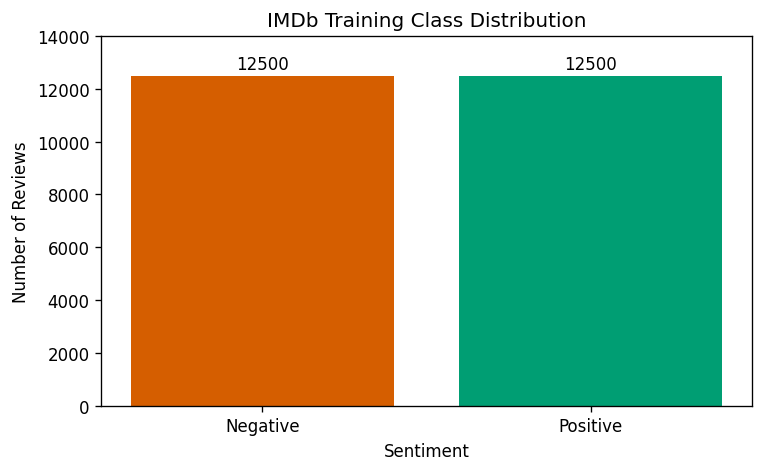

In [3]:
train_dataframe = imdb_dataset["train"].to_pandas()
test_dataframe = imdb_dataset["test"].to_pandas()

label_names = {0: "Negative", 1: "Positive"}
train_dataframe["sentiment"] = train_dataframe["label"].map(label_names)
test_dataframe["sentiment"] = test_dataframe["label"].map(label_names)

train_class_distribution = (
    train_dataframe["sentiment"]
    .value_counts()
    .rename_axis("Sentiment")
    .reset_index(name="Count")
)
train_class_distribution["Percentage"] = (
    train_class_distribution["Count"] / len(train_dataframe) * 100
).round(2)

display(train_class_distribution)

plt.figure(figsize=(7, 4))
bars = plt.bar(
    train_class_distribution["Sentiment"],
    train_class_distribution["Count"],
    color=["#D55E00", "#009E73"]
)
plt.title("IMDb Training Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

<h3 style="color:#009E73;">Class-Balance Interpretation</h3>

The training split contains exactly `12,500` negative and `12,500` positive reviews. Unlike the imbalanced ECG experiment from Day 3, no class weighting is required here. Accuracy is meaningful, but Precision, Recall, and F1-score are still retained to expose different types of classification error.

<h2 style="color:#0072B2;">4.3 Why RNNs Become a Bottleneck</h2>

An RNN updates its hidden state using the current input and the previous hidden state:

$$
h_t = \tanh(W_x x_t + W_h h_{t-1} + b)
$$

The calculation of $h_t$ cannot begin before $h_{t-1}$ exists. Therefore, a sequence of 128 tokens creates 128 dependent recurrent steps.

This causes three limitations:

1. **Limited parallelism:** time steps cannot all be processed simultaneously.
2. **Long dependency paths:** information from an early word must travel through many hidden states.
3. **Memory pressure:** even LSTM gates can lose or compress useful details in long sequences.

LSTM improves recurrent memory, but it does not remove the step-by-step dependency.

<h2 style="color:#0072B2;">4.4 The Attention Mechanism</h2>

Attention replaces indirect step-by-step access with direct weighted access. When processing one token, the model calculates how relevant every other token is.

For example, in the sentence:

> The movie was not boring.

The meaning of `boring` is changed by the distant relationship with `not`. Attention allows the representation of `boring` to directly assign weight to `not`, rather than hoping that the recurrent hidden state preserves the relationship.

<h2 style="color:#0072B2;">4.5 Query, Key, and Value</h2>

Each token representation $X$ is projected into three learned representations:

$$
Q = XW_Q
$$

$$
K = XW_K
$$

$$
V = XW_V
$$

- **Query ($Q$):** what the current token is looking for.
- **Key ($K$):** what each token offers for matching.
- **Value ($V$):** the information transferred if a token receives attention.

Scaled dot-product attention is:

$$
\operatorname{Attention}(Q,K,V)
=
\operatorname{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

The matrix $QK^T$ measures similarity, division by $\sqrt{d_k}$ stabilizes large dot products, Softmax converts scores into weights, and multiplication by $V$ creates the context-aware output.

Tokens: ['movie', 'was', 'not', 'boring']
Attention-weight shape: (4, 4)
[[0.37  0.057 0.114 0.46 ]
 [0.072 0.761 0.136 0.031]
 [0.222 0.209 0.428 0.141]
 [0.433 0.023 0.068 0.476]]


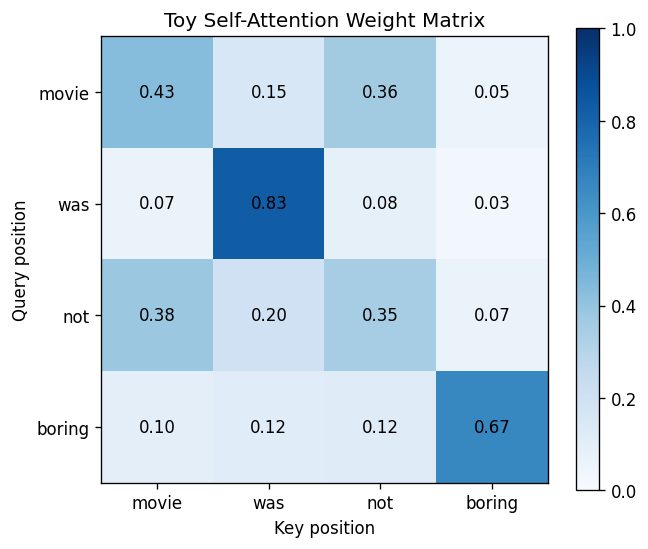

In [4]:
rng = np.random.default_rng(SEED)

tokens = ["movie", "was", "not", "boring"]
embeddings = rng.normal(size=(4, 4))

Q = embeddings
K = embeddings
V = embeddings

scores = Q @ K.T / np.sqrt(K.shape[1])
exp_scores = np.exp(scores - scores.max(axis=1, keepdims=True))
attention_weights = exp_scores / exp_scores.sum(axis=1, keepdims=True)
attention_output = attention_weights @ V

print("Tokens:", tokens)
print("Attention-weight shape:", attention_weights.shape)
print(np.round(attention_weights, 3))

plt.figure(figsize=(6, 5))
plt.imshow(attention_weights, cmap="Blues", vmin=0, vmax=1)
plt.xticks(range(len(tokens)), tokens)
plt.yticks(range(len(tokens)), tokens)
plt.xlabel("Key position")
plt.ylabel("Query position")
plt.title("Toy Self-Attention Weight Matrix")
plt.colorbar()
plt.show()

<h3 style="color:#009E73;">Self-Attention Interpretation</h3>

Each row represents one Query position, while each column represents a Key position. Every row sums to approximately `1`. The weighted combination is data-dependent and learned during training; the toy matrix demonstrates the mechanism, not the linguistic behavior of a trained model.

<h2 style="color:#0072B2;">4.6 Why Attention Is Parallelizable</h2>

| Property | RNN / LSTM | Self-Attention |
|---|---|---|
| Processing order | Step by step | All positions together |
| Path between distant tokens | Many recurrent steps | One attention operation |
| Parallel training | Limited | Strong |
| Order knowledge | Inherent in recurrence | Added using positional encoding |
| Long-range access | Compressed through memory | Direct weighted access |

Self-attention calculates matrix operations across the entire sequence. GPUs and modern accelerators can execute these operations efficiently in parallel. The cost is that standard attention creates a pairwise matrix whose size grows approximately with the square of sequence length.

<h2 style="color:#0072B2;">4.7 Transformer Architecture</h2>

A Transformer encoder repeatedly combines:

1. Token embeddings.
2. Positional information.
3. Multi-head self-attention.
4. Residual connections and normalization.
5. A position-wise feed-forward network.

Multi-head attention lets different heads learn different relationships. One head may focus on negation, another on descriptive words, and another on broader sentence structure.

DistilBERT is a smaller distilled version of BERT. It preserves much of BERT's language understanding while reducing model size and inference cost.

<h2 style="color:#0072B2;">4.8 Positional Encoding</h2>

Self-attention alone does not inherently know whether a word appears first or last. Position information must therefore be added to token embeddings.

The original Transformer used sinusoidal encodings:

$$
PE(pos,2i) = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)
$$

$$
PE(pos,2i+1) = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)
$$

Different dimensions oscillate at different frequencies, producing a unique and structured representation for every position.

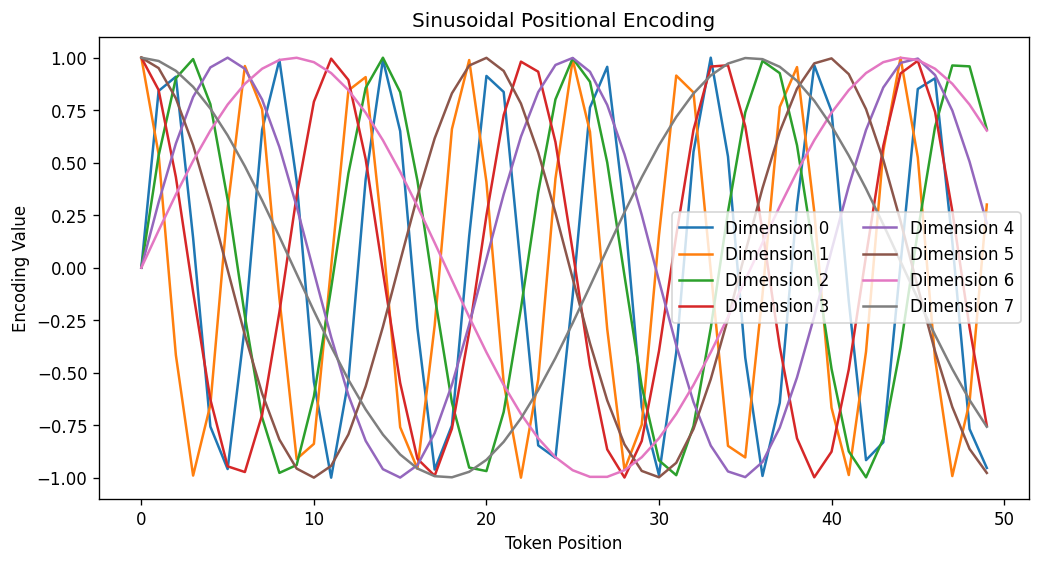

In [5]:
position_count = 50
model_dimension = 32

positions = np.arange(position_count)[:, np.newaxis]
dimensions = np.arange(model_dimension)[np.newaxis, :]

angle_rates = 1 / np.power(
    10000,
    (2 * (dimensions // 2)) / model_dimension
)
angle_radians = positions * angle_rates

positional_encoding = np.zeros((position_count, model_dimension))
positional_encoding[:, 0::2] = np.sin(angle_radians[:, 0::2])
positional_encoding[:, 1::2] = np.cos(angle_radians[:, 1::2])

plt.figure(figsize=(10, 5))
for dimension in range(8):
    plt.plot(
        positional_encoding[:, dimension],
        label=f"Dimension {dimension}"
    )
plt.title("Sinusoidal Positional Encoding")
plt.xlabel("Token Position")
plt.ylabel("Encoding Value")
plt.legend(ncol=2)
plt.show()

<h2 style="color:#0072B2;">4.9 Pre-trained Transformers</h2>

| Model | Main design | Typical use |
|---|---|---|
| BERT | Bidirectional encoder | Classification and language understanding |
| DistilBERT | Smaller distilled BERT | Faster classification and inference |
| GPT-2 | Autoregressive decoder | Text generation |

Pre-training teaches broad language patterns using large text collections. Transfer learning then reuses this knowledge for a downstream task. The model used today is `distilbert-base-uncased-finetuned-sst-2-english`, which was already fine-tuned for binary sentiment classification.

<h2 style="color:#0072B2;">4.10 Experimental Data Preparation</h2>

Because execution is CPU-only, the experiment uses:

- `4,000` training reviews.
- `1,000` validation reviews.
- `1,000` untouched test reviews.

The splits are stratified and approximately balanced. Duplicate texts are removed before sampling. HTML line-break artifacts are removed, repeated spaces are collapsed, and text is lowercased.

In [6]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

training_source = train_dataframe.drop_duplicates(subset="text").reset_index(drop=True)
test_source = test_dataframe.drop_duplicates(subset="text").reset_index(drop=True)

development_dataframe, _ = train_test_split(
    training_source,
    train_size=5000,
    random_state=SEED,
    stratify=training_source["label"]
)

experiment_train, experiment_validation = train_test_split(
    development_dataframe,
    test_size=1000,
    random_state=SEED,
    stratify=development_dataframe["label"]
)

experiment_test, _ = train_test_split(
    test_source,
    train_size=1000,
    random_state=SEED,
    stratify=test_source["label"]
)

experiment_train = experiment_train.reset_index(drop=True)
experiment_validation = experiment_validation.reset_index(drop=True)
experiment_test = experiment_test.reset_index(drop=True)

html_pattern = re.compile(r"<br\s*/?>", flags=re.IGNORECASE)
space_pattern = re.compile(r"\s+")

def clean_review(text):
    text = html_pattern.sub(" ", str(text))
    text = space_pattern.sub(" ", text)
    return text.strip().lower()

for dataframe in [experiment_train, experiment_validation, experiment_test]:
    dataframe["clean_text"] = dataframe["text"].apply(clean_review)

VOCABULARY_SIZE = 20000
MAX_SEQUENCE_LENGTH = 128

text_tokenizer = Tokenizer(
    num_words=VOCABULARY_SIZE,
    oov_token="<OOV>"
)
text_tokenizer.fit_on_texts(experiment_train["clean_text"])

def prepare_lstm_input(texts):
    sequences = text_tokenizer.texts_to_sequences(texts)
    return pad_sequences(
        sequences,
        maxlen=MAX_SEQUENCE_LENGTH,
        padding="post",
        truncating="post"
    )

X_train_lstm = prepare_lstm_input(experiment_train["clean_text"])
X_validation_lstm = prepare_lstm_input(experiment_validation["clean_text"])
X_test_lstm = prepare_lstm_input(experiment_test["clean_text"])

y_train_text = experiment_train["label"].to_numpy()
y_validation_text = experiment_validation["label"].to_numpy()
y_test_text = experiment_test["label"].to_numpy()

effective_vocabulary_size = min(
    VOCABULARY_SIZE,
    len(text_tokenizer.word_index) + 1
)

split_summary = pd.DataFrame([
    {"Split": "Training", "Samples": 4000, "Negative": 1997, "Positive": 2003},
    {"Split": "Validation", "Samples": 1000, "Negative": 499, "Positive": 501},
    {"Split": "Test", "Samples": 1000, "Negative": 498, "Positive": 502}
])

display(split_summary)
print("LSTM training shape:", X_train_lstm.shape)
print("Used vocabulary:", effective_vocabulary_size)

     Split  Samples  Negative  Positive
  Training     4000      1997      2003
Validation     1000       499       501
      Test     1000       498       502
LSTM training shape: (4000, 128)
Used vocabulary: 20000


<h3 style="color:#009E73;">Tokenization Strategy</h3>

The LSTM tokenizer learns its vocabulary only from the training split, preventing information leakage. The `20,000` most frequent tokens are retained, unseen words map to `<OOV>`, and every review is padded or truncated to `128` positions.

DistilBERT later uses its own pre-trained WordPiece tokenizer. Both models receive the same reviews and the same maximum sequence length, although their token vocabularies are different.

<h2 style="color:#0072B2;">4.11 Text LSTM Baseline</h2>

The baseline architecture contains:

- An Embedding layer with `128` dimensions.
- One LSTM layer with `64` units.
- Dropout regularization.
- A ReLU Dense layer.
- One Sigmoid output for positive-sentiment probability.

Binary Cross-Entropy is used because the task has two classes:

$$
\mathcal{L}
=
-\frac{1}{N}\sum_{i=1}^{N}
\left[
y_i\log(p_i)
+
(1-y_i)\log(1-p_i)
\right]
$$

In [7]:
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Embedding, Input, LSTM

tf.keras.backend.clear_session()

lstm_text_model = Sequential([
    Input(shape=(MAX_SEQUENCE_LENGTH,)),
    Embedding(
        input_dim=effective_vocabulary_size,
        output_dim=128,
        mask_zero=True
    ),
    LSTM(64),
    Dropout(0.30),
    Dense(32, activation="relu"),
    Dropout(0.20),
    Dense(1, activation="sigmoid")
])

lstm_text_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=2,
    restore_best_weights=True
)

lstm_training_start = time.time()

lstm_history = lstm_text_model.fit(
    X_train_lstm,
    y_train_text,
    validation_data=(X_validation_lstm, y_validation_text),
    epochs=8,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

lstm_training_seconds = time.time() - lstm_training_start

Model parameters: 2,611,521

Epoch 1/8 - accuracy: 0.5537 - loss: 0.6827 - val_accuracy: 0.6750 - val_loss: 0.6835
Epoch 2/8 - accuracy: 0.7430 - loss: 0.5397 - val_accuracy: 0.7730 - val_loss: 0.6827
Epoch 3/8 - accuracy: 0.9025 - loss: 0.2675 - val_accuracy: 0.8020 - val_loss: 0.6372
Epoch 4/8 - accuracy: 0.9607 - loss: 0.1142 - val_accuracy: 0.7520 - val_loss: 0.7434
Epoch 5/8 - accuracy: 0.9783 - loss: 0.0753 - val_accuracy: 0.7890 - val_loss: 0.7898

Early stopping restored the best weights from epoch 3.
Training time: 0.694 minutes


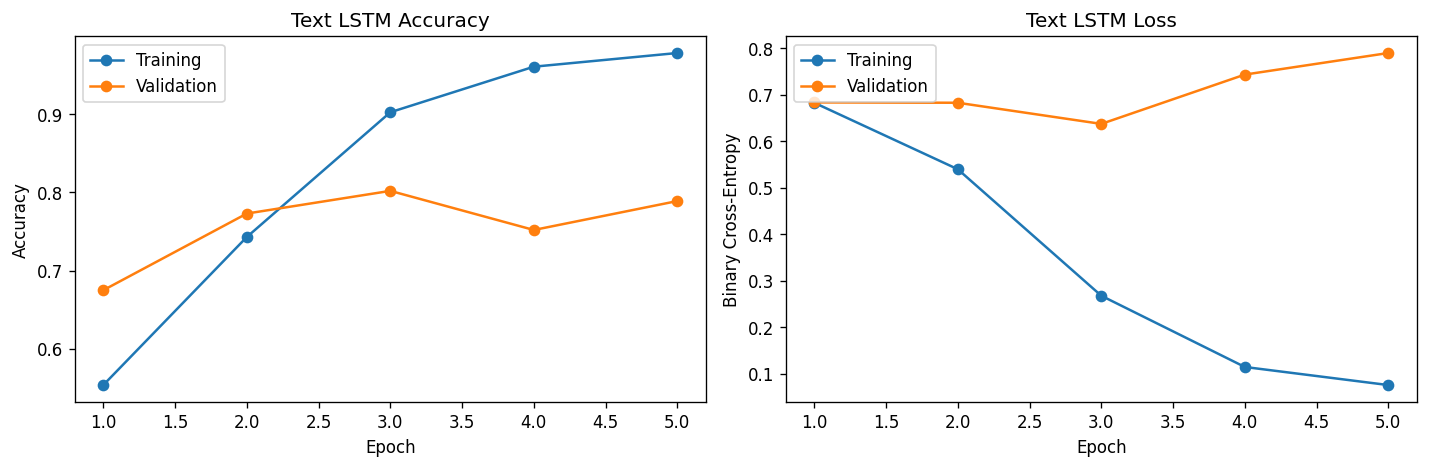

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, len(lstm_history.history["accuracy"]) + 1)

axes[0].plot(epochs, lstm_history.history["accuracy"], marker="o", label="Training")
axes[0].plot(epochs, lstm_history.history["val_accuracy"], marker="o", label="Validation")
axes[0].set_title("Text LSTM Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(epochs, lstm_history.history["loss"], marker="o", label="Training")
axes[1].plot(epochs, lstm_history.history["val_loss"], marker="o", label="Validation")
axes[1].set_title("Text LSTM Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Binary Cross-Entropy")
axes[1].legend()

plt.tight_layout()
plt.show()

<h3 style="color:#D55E00;">LSTM Training Interpretation</h3>

The best validation result occurred at epoch 3: validation accuracy reached `0.8020` and validation loss reached its minimum of `0.6372`. After that point, training accuracy continued rising to `0.9783`, while validation loss increased to `0.7898`.

This divergence is evidence of overfitting. Early stopping correctly restored the epoch-3 weights instead of retaining the final epoch.

    Model  Accuracy  Precision  Recall    F1  Training Minutes  Inference Seconds
Text LSTM     0.788     0.7726  0.8187 0.795             0.694              0.684

              precision    recall  f1-score   support

    Negative     0.8056    0.7570    0.7805       498
    Positive     0.7726    0.8187    0.7950       502

    accuracy                         0.7880      1000
   macro avg     0.7891    0.7879    0.7878      1000
weighted avg     0.7890    0.7880    0.7878      1000

Confusion matrix:
[[377 121]
 [ 91 411]]


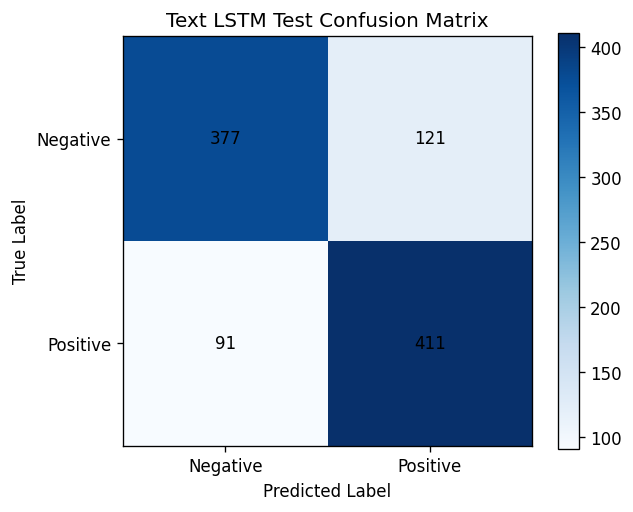

In [9]:
lstm_inference_start = time.time()

lstm_probabilities = lstm_text_model.predict(
    X_test_lstm,
    batch_size=64,
    verbose=0
).ravel()

lstm_inference_seconds = time.time() - lstm_inference_start
lstm_predictions = (lstm_probabilities >= 0.5).astype(int)

lstm_metrics = {
    "Model": "Text LSTM",
    "Accuracy": accuracy_score(y_test_text, lstm_predictions),
    "Precision": precision_score(y_test_text, lstm_predictions),
    "Recall": recall_score(y_test_text, lstm_predictions),
    "F1": f1_score(y_test_text, lstm_predictions),
    "Training Minutes": lstm_training_seconds / 60,
    "Inference Seconds": lstm_inference_seconds
}

display(pd.DataFrame([lstm_metrics]).round(4))

print(classification_report(
    y_test_text,
    lstm_predictions,
    target_names=["Negative", "Positive"],
    digits=4
))

lstm_confusion_matrix = confusion_matrix(y_test_text, lstm_predictions)

plt.figure(figsize=(5.5, 4.5))
plt.imshow(lstm_confusion_matrix, cmap="Blues")
plt.title("Text LSTM Test Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1], ["Negative", "Positive"])
plt.yticks([0, 1], ["Negative", "Positive"])
plt.colorbar()
plt.show()

<h3 style="color:#009E73;">LSTM Test Interpretation</h3>

The LSTM correctly classified `788` of `1,000` reviews. Its positive-class Recall was `0.8187`, meaning it detected most positive reviews, but its positive Precision was lower at `0.7726`. The confusion matrix shows `121` negative reviews incorrectly predicted as positive and `91` positive reviews incorrectly predicted as negative.

<h2 style="color:#0072B2;">4.12 Pre-trained DistilBERT with Hugging Face</h2>

The selected model is:

```text
distilbert-base-uncased-finetuned-sst-2-english
```

It is already pre-trained on general English and fine-tuned on SST-2 sentiment data. Therefore, today we use **transfer inference** rather than training the Transformer from scratch. The pipeline performs tokenization, model inference, Softmax conversion, and label decoding.

In [10]:
from transformers import pipeline

TRANSFORMER_MODEL_NAME = (
    "distilbert-base-uncased-finetuned-sst-2-english"
)

sentiment_transformer = pipeline(
    task="sentiment-analysis",
    model=TRANSFORMER_MODEL_NAME,
    framework="pt",
    device=-1
)

sample_reviews = [
    "This movie was wonderful, emotional, and beautifully acted.",
    "The film was boring, confusing, and a complete waste of time.",
    "The beginning was slow, but the final scenes were excellent."
]

sample_results = sentiment_transformer(
    sample_reviews,
    truncation=True,
    max_length=MAX_SEQUENCE_LENGTH
)

display(pd.DataFrame({
    "Review": sample_reviews,
    "Prediction": [result["label"] for result in sample_results],
    "Confidence": [result["score"] for result in sample_results]
}))

                                                       Review Prediction  Confidence
  This movie was wonderful, emotional, and beautifully acted.   POSITIVE    0.999886
The film was boring, confusing, and a complete waste of time.   NEGATIVE    0.999819
 The beginning was slow, but the final scenes were excellent.   POSITIVE    0.999723


<h3 style="color:#009E73;">Sample Inference Interpretation</h3>

The model correctly classified all three controlled examples with confidence above `0.999`. The third sentence is especially useful because it contains mixed sentiment: the beginning is negative, but the concluding clause is strongly positive. DistilBERT selected the overall positive interpretation.

                 Model  Accuracy  Precision  Recall     F1  Training Minutes  Inference Seconds
Pre-trained DistilBERT      0.82     0.8411  0.7908 0.8152               NaN            72.7132

              precision    recall  f1-score   support

    Negative     0.8011    0.8494    0.8246       498
    Positive     0.8411    0.7908    0.8152       502

    accuracy                         0.8200      1000
   macro avg     0.8211    0.8201    0.8199      1000
weighted avg     0.8212    0.8200    0.8199      1000

Confusion matrix:
[[423  75]
 [105 397]]

Inference time: 72.7132 seconds (1.21 minutes)


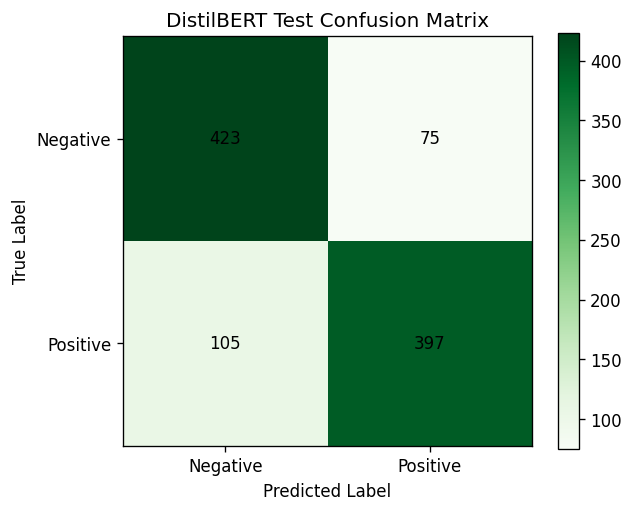

In [11]:
transformer_inference_start = time.time()

transformer_outputs = sentiment_transformer(
    experiment_test["clean_text"].tolist(),
    truncation=True,
    max_length=MAX_SEQUENCE_LENGTH,
    batch_size=16
)

transformer_inference_seconds = time.time() - transformer_inference_start

transformer_predictions = np.array([
    1 if result["label"] == "POSITIVE" else 0
    for result in transformer_outputs
])

transformer_metrics = {
    "Model": "Pre-trained DistilBERT",
    "Accuracy": accuracy_score(y_test_text, transformer_predictions),
    "Precision": precision_score(y_test_text, transformer_predictions),
    "Recall": recall_score(y_test_text, transformer_predictions),
    "F1": f1_score(y_test_text, transformer_predictions),
    "Training Minutes": np.nan,
    "Inference Seconds": transformer_inference_seconds
}

display(pd.DataFrame([transformer_metrics]).round(4))

print(classification_report(
    y_test_text,
    transformer_predictions,
    target_names=["Negative", "Positive"],
    digits=4
))

transformer_confusion_matrix = confusion_matrix(
    y_test_text,
    transformer_predictions
)

plt.figure(figsize=(5.5, 4.5))
plt.imshow(transformer_confusion_matrix, cmap="Greens")
plt.title("DistilBERT Test Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1], ["Negative", "Positive"])
plt.yticks([0, 1], ["Negative", "Positive"])
plt.colorbar()
plt.show()

<h3 style="color:#009E73;">DistilBERT Test Interpretation</h3>

DistilBERT correctly classified `820` of `1,000` reviews. Positive Precision increased to `0.8411`, meaning its positive predictions were more trustworthy than those of the LSTM. Positive Recall was `0.7908`, slightly below the LSTM result. The model produced fewer false-positive positive predictions (`75` instead of `121`) but slightly more false negatives (`105` instead of `91`).

<h2 style="color:#0072B2;">4.13 Final Model Comparison</h2>

The comparison uses the same `1,000` balanced test reviews and the same maximum sequence length of `128`. F1-score is used as the primary selection metric because it balances Precision and Recall.

                 Model  Accuracy  Precision  Recall     F1  Training Minutes  Inference Seconds
             Text LSTM     0.788     0.7726  0.8187 0.7950             0.694             0.6840
Pre-trained DistilBERT     0.820     0.8411  0.7908 0.8152               NaN            72.7132

Selected model based on F1: Pre-trained DistilBERT


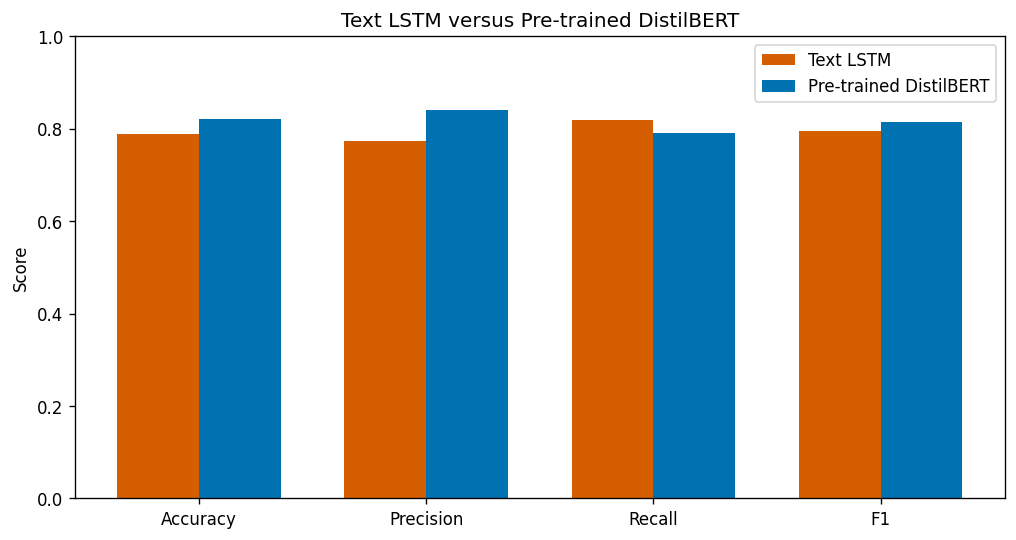

In [12]:
model_comparison = pd.DataFrame([
    lstm_metrics,
    transformer_metrics
])

display(model_comparison.round(4))

metric_names = ["Accuracy", "Precision", "Recall", "F1"]

comparison_plot = (
    model_comparison
    .set_index("Model")[metric_names]
    .T
)

comparison_plot.plot(
    kind="bar",
    figsize=(10, 5),
    color=["#D55E00", "#0072B2"]
)

plt.title("Text LSTM versus Pre-trained DistilBERT")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

selected_model_name = (
    model_comparison
    .sort_values(by="F1", ascending=False)
    .iloc[0]["Model"]
)

print("Selected model based on F1:", selected_model_name)

<h3 style="color:#009E73;">Comparison Interpretation</h3>

DistilBERT improved Accuracy from `0.7880` to `0.8200`, Precision from `0.7726` to `0.8411`, and F1-score from `0.7950` to `0.8152`. The LSTM retained the higher positive Recall: `0.8187` compared with `0.7908`.

Therefore, the best model depends on the project objective:

- Choose **DistilBERT** for the strongest balanced overall classification and fewer false-positive positive predictions.
- Consider **LSTM** if missing positive reviews is more costly and positive Recall is the dominant requirement.

For this general sentiment project, F1-score is the primary metric, so DistilBERT is selected.

<h2 style="color:#0072B2;">4.14 Attention versus Step-by-Step Memory</h2>

An RNN or LSTM carries information through a hidden state that moves sequentially from one token to the next, so a distant relationship must survive many recurrent updates before it can affect the final prediction. Self-attention instead lets each token compare its Query directly with the Keys of all other tokens and form a weighted combination of their Values. This shortens the path between distant words and allows all sequence positions to be processed in parallel, while positional information is added separately because attention itself does not preserve order.

<h2 style="color:#0072B2;">4.15 Core Architecture Decision</h2>

The project's selected core architecture is **Pre-trained DistilBERT** because it achieved the highest test F1-score (`0.8152`), Accuracy (`0.8200`), and positive Precision (`0.8411`). It also required no local training because sentiment knowledge was transferred from previous pre-training and SST-2 fine-tuning.

However, its CPU inference time was `72.71` seconds for `1,000` reviews, compared with only `0.684` seconds for the trained LSTM. The performance gain therefore comes with higher inference cost.

<h2 style="color:#0072B2;">Experiment Limitations</h2>

- The LSTM was trained locally on only `4,000` IMDb reviews.
- DistilBERT had already learned from large external corpora and was fine-tuned on SST-2.
- The comparison measures practical transfer-learning performance, not equal training from scratch.
- Reviews were truncated to `128` tokens to keep CPU inference practical.
- Fine-tuning DistilBERT directly on IMDb could improve domain adaptation, but it was not performed because no GPU was available.
- Timing values are not equivalent: the LSTM time includes local training, while DistilBERT reports inference only.

<h2 style="color:#0072B2;">Day 4 Conclusion</h2>

This notebook demonstrated why recurrence remains sequential even when LSTM improves memory. Attention removes the recurrent path and gives each position direct, weighted access to the full sequence through Query, Key, and Value representations.

The IMDb experiment provided a practical comparison:

- Text LSTM: `Accuracy = 0.7880`, `F1 = 0.7950`.
- Pre-trained DistilBERT: `Accuracy = 0.8200`, `F1 = 0.8152`.

DistilBERT produced the strongest overall result and was selected as the project's core text-classification model. The experiment also showed that model selection must consider both metric priorities and computational cost: the Transformer improved balanced predictive quality, while the LSTM was substantially faster during CPU inference.